# Phase 2 — Modelling

**Timeseries:** `596eef7c71f933d820d0e485935d0e8f` | Beauty & Fitness / Hair Care | US | USD

Steps covered:
- Step 3: Adstock & saturation transformations (`mmm/transformations.py`)
- Step 4: PyMC-Marketing model definition (`mmm/model.py`)
- Step 5: Model training, convergence diagnostics

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mmm.preprocessing import train_holdout_split, PAID_CHANNEL_COLS, CONTROL_COLS, TARGET_COL
from mmm.transformations import geometric_adstock, hill_saturation, adstock_saturation

# Load clean data produced by 01-eda.ipynb
df_clean = pd.read_csv("../data/mmm_data_clean.csv", parse_dates=["date_day"])
train, holdout = train_holdout_split(df_clean)

print(f"Train shape:   {train.shape}")
print(f"Holdout shape: {holdout.shape}")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Train shape:   (407, 59)
Holdout shape: (102, 59)


## Step 3 — Visualise Adstock & Saturation

Sanity-check transformations before wiring them into PyMC.

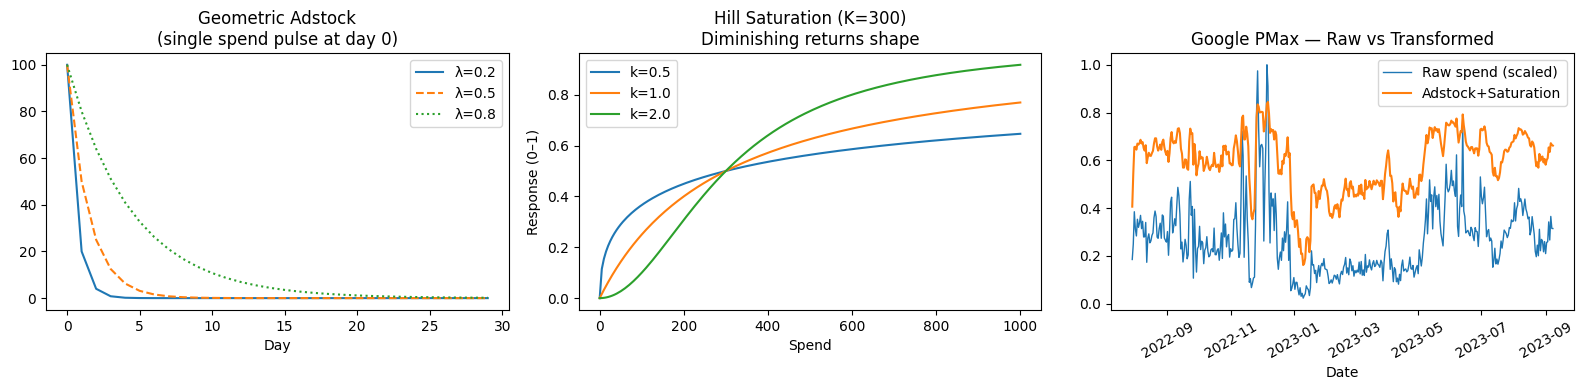

In [7]:
x = np.zeros(30)
x[0] = 100  # Single spike of 100 on day 0

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Adstock — different decay rates
for lam, ls in [(0.2, "-"), (0.5, "--"), (0.8, ":")]:
    axes[0].plot(geometric_adstock(x, lam), label=f"λ={lam}", linestyle=ls)
axes[0].set_title("Geometric Adstock\n(single spend pulse at day 0)")
axes[0].set_xlabel("Day")
axes[0].legend()

# Hill saturation — shape of response curve
spend_range = np.linspace(0, 1000, 200)
for k in [0.5, 1.0, 2.0]:
    axes[1].plot(spend_range, hill_saturation(spend_range, k=k, K=300), label=f"k={k}")
axes[1].set_title("Hill Saturation (K=300)\nDiminishing returns shape")
axes[1].set_xlabel("Spend")
axes[1].set_ylabel("Response (0–1)")
axes[1].legend()

# Combined adstock → saturation for actual PMax spend
pmax = train["google_pmax_spend"].values
transformed = adstock_saturation(pmax, lam=0.4, k=1.0, K=pmax[pmax > 0].mean())
axes[2].plot(train["date_day"], pmax / pmax.max(), lw=1, label="Raw spend (scaled)")
axes[2].plot(train["date_day"], transformed, lw=1.5, label="Adstock+Saturation")
axes[2].set_title("Google PMax — Raw vs Transformed")
axes[2].set_xlabel("Date")
axes[2].legend()
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Step 4 — Build PyMC-Marketing Model

`mmm/model.py` will be implemented here and then extracted into the module.

In [14]:
import importlib, mmm.model
importlib.reload(mmm.model)

import pymc_marketing
print(f"pymc-marketing: {pymc_marketing.__version__}")

from mmm.model import build_mmm, prepare_model_data, CHANNEL_COLS, MODEL_CONTROL_COLS
print(f"Channels:  {CHANNEL_COLS}")
print(f"Controls:  {MODEL_CONTROL_COLS}")
print("Model imports OK")

pymc-marketing: 0.19.4
Channels:  ['total_google_spend_norm', 'total_meta_spend_norm']
Controls:  ['direct_clicks_scaled', 'branded_search_clicks_scaled', 'organic_search_clicks_scaled', 'email_clicks_scaled', 'referral_clicks_scaled', 'all_other_clicks_scaled', 'is_weekend', 'is_holiday']
Model imports OK


## Step 4 — Prepare Feature Matrix

In [15]:
X_train, y_train, scaler = prepare_model_data(train)
X_holdout, y_holdout, _ = prepare_model_data(holdout, scaler=scaler)

# Only keep control columns that actually exist in the feature matrix
active_controls = [c for c in MODEL_CONTROL_COLS if c in X_train.columns]

print(f"X_train shape  : {X_train.shape}")
print(f"X_holdout shape: {X_holdout.shape}")
print(f"\nChannels  ({len(CHANNEL_COLS)}): {CHANNEL_COLS}")
print(f"Controls  ({len(active_controls)}): {active_controls}")
print(f"\nChannel spend range (should be [0, 1]):")
for col in CHANNEL_COLS:
    print(f"  {col}: [{X_train[col].min():.3f}, {X_train[col].max():.3f}]")
X_train.head(3)

X_train shape  : (407, 11)
X_holdout shape: (102, 11)

Channels  (2): ['total_google_spend_norm', 'total_meta_spend_norm']
Controls  (8): ['direct_clicks_scaled', 'branded_search_clicks_scaled', 'organic_search_clicks_scaled', 'email_clicks_scaled', 'referral_clicks_scaled', 'all_other_clicks_scaled', 'is_weekend', 'is_holiday']

Channel spend range (should be [0, 1]):
  total_google_spend_norm: [0.046, 1.000]
  total_meta_spend_norm: [0.000, 1.000]


,date_day,total_google_spend_norm,total_meta_spend_norm,direct_clicks_scaled,branded_search_clicks_scaled,organic_search_clicks_scaled,email_clicks_scaled,referral_clicks_scaled,all_other_clicks_scaled,is_weekend,is_holiday
0,2022-07-29,0.138485,0.141092,-0.870170,-1.534983,-1.036244,-0.608954,-1.433985,-0.515175,0,0
1,2022-07-30,0.186698,0.150200,-0.417794,-1.534983,0.367485,-0.585818,-1.108779,-0.380304,1,0
2,2022-07-31,0.288007,0.165695,-0.075280,-1.534983,0.219204,1.473300,-1.122053,-0.361912,1,0


## Step 4 — Build MMM Model

Build the PyMC-Marketing model graph and inspect the prior structure.

In [16]:
mmm = build_mmm(control_columns=active_controls)
mmm.build_model(X_train, y_train)
print(mmm.model)

c:\Users\Rodrigo Guskuma\Documents\vscode\personal-projects\mmm-analysis\.venv\Lib\site-packages\pydantic\_internal\_validate_call.py:137: FutureWarning: 
            The MMM class is deprecated and will be removed in a future version (in version 0.20.0).
            Please use the multidimensional MMM class instead.
            That is, `from pymc_marketing.mmm.multidimensional import MMM`.
            All our documentation has been updated to reflect this change.
            Refer to the migration guide for more details: https://www.pymc-marketing.io/en/latest/notebooks/mmm/mmm_migration_guide.html
            
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))


## Step 5 — Sample (MCMC)

Uses `numpyro` as the NUTS sampler — JAX/XLA compiles the model to native code, bypassing Python-mode PyTensor entirely (~20–50× faster on CPU).

Run the **benchmark cell first** to estimate how long your chosen config will take, then run the fit cell below it.

In [5]:
import time

print("Benchmarking numpyro sampler (includes one-time JIT compilation)...\n")

_mmm_bench = build_mmm(control_columns=active_controls)
_mmm_bench.build_model(X_train, y_train)

BENCH_DRAWS, BENCH_TUNE = 25, 25
t0 = time.perf_counter()
_mmm_bench.fit(
    X=X_train, y=y_train,
    draws=BENCH_DRAWS, tune=BENCH_TUNE, chains=1,
    nuts_sampler="numpyro",
    random_seed=0, progressbar=False,
)
t_bench = time.perf_counter() - t0
bench_steps = BENCH_DRAWS + BENCH_TUNE
ms_per_step = t_bench / bench_steps * 1000

print(f"  {bench_steps} steps in {t_bench:.1f}s  →  {ms_per_step:.0f} ms/step\n")

configs = [
    ("Quick check",  200, 200, 2),
    ("Standard  ◀", 500, 500, 2),
    ("Production",  2000, 1000, 4),
]
print(f"{'Config':<16} {'Draws':>6} {'Tune':>6} {'Chains':>7}  {'Est. time':>12}")
print("─" * 54)
for name, draws, tune, chains in configs:
    est_min = (draws + tune) * chains * ms_per_step / 1000 / 60
    print(f"{name:<16} {draws:>6} {tune:>6} {chains:>7}  {est_min:>10.1f} min")

c:\Users\Rodrigo Guskuma\Documents\vscode\personal-projects\mmm-analysis\.venv\Lib\site-packages\pydantic\_internal\_validate_call.py:137: FutureWarning: 
            The MMM class is deprecated and will be removed in a future version (in version 0.20.0).
            Please use the multidimensional MMM class instead.
            That is, `from pymc_marketing.mmm.multidimensional import MMM`.
            All our documentation has been updated to reflect this change.
            Refer to the migration guide for more details: https://www.pymc-marketing.io/en/latest/notebooks/mmm/mmm_migration_guide.html
            
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))
Only 25 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Benchmarking numpyro sampler (includes one-time JIT compilation)...



There were 12 divergences after tuning. Increase `target_accept` or reparameterize.
The number of samples is too small to check convergence reliably.


Output()

  50 steps in 12.9s  →  258 ms/step

Config            Draws   Tune  Chains     Est. time
──────────────────────────────────────────────────────
Quick check         200    200       2         3.4 min
Standard  ◀         500    500       2         8.6 min
Production         2000   1000       4        51.5 min


In [21]:
idata = mmm.fit(
    X=X_train,
    y=y_train,
    draws=500,
    tune=1000,
    chains=4,           # 4 chains for robust R-hat and ESS diagnostics
    nuts_sampler="numpyro",
    target_accept=0.95,
    random_seed=42,
    progressbar=True,
)
print("Sampling complete.")

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

Output()

Sampling complete.


## Step 5 — Convergence Diagnostics

In [22]:
import arviz as az

# ── R-hat and ESS ──────────────────────────────────────────────────────────
rhat_vals = az.rhat(idata)
max_rhat = float(rhat_vals.to_array().max())
n_divergences = int(idata.sample_stats["diverging"].values.sum())

print(f"Max R-hat   : {max_rhat:.4f}  (target < 1.01)")
print(f"Divergences : {n_divergences}         (target = 0)")

# ── Posterior summary for key parameters ──────────────────────────────────
summary = az.summary(
    idata,
    var_names=["intercept", "saturation_lam", "saturation_beta"],
    round_to=3,
)
print("\nPosterior summary (key parameters):")
print(summary.to_string())

c:\Users\Rodrigo Guskuma\Documents\vscode\personal-projects\mmm-analysis\.venv\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


Max R-hat   : 1.0057  (target < 1.01)
Divergences : 0         (target = 0)

Posterior summary (key parameters):
                                           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
intercept                                 0.060  0.006   0.049    0.070      0.000    0.000  1204.417  1157.646  1.002
saturation_lam[total_google_spend_norm]   3.250  2.152   0.065    7.071      0.058    0.044  1028.403   635.161  1.000
saturation_lam[total_meta_spend_norm]     1.292  0.826   0.064    2.726      0.024    0.022   989.672  1121.995  1.001
saturation_beta[total_google_spend_norm]  0.027  0.042   0.000    0.058      0.002    0.007   777.382   669.261  1.002
saturation_beta[total_meta_spend_norm]    0.259  0.258   0.035    0.651      0.009    0.018   930.809  1013.833  1.000


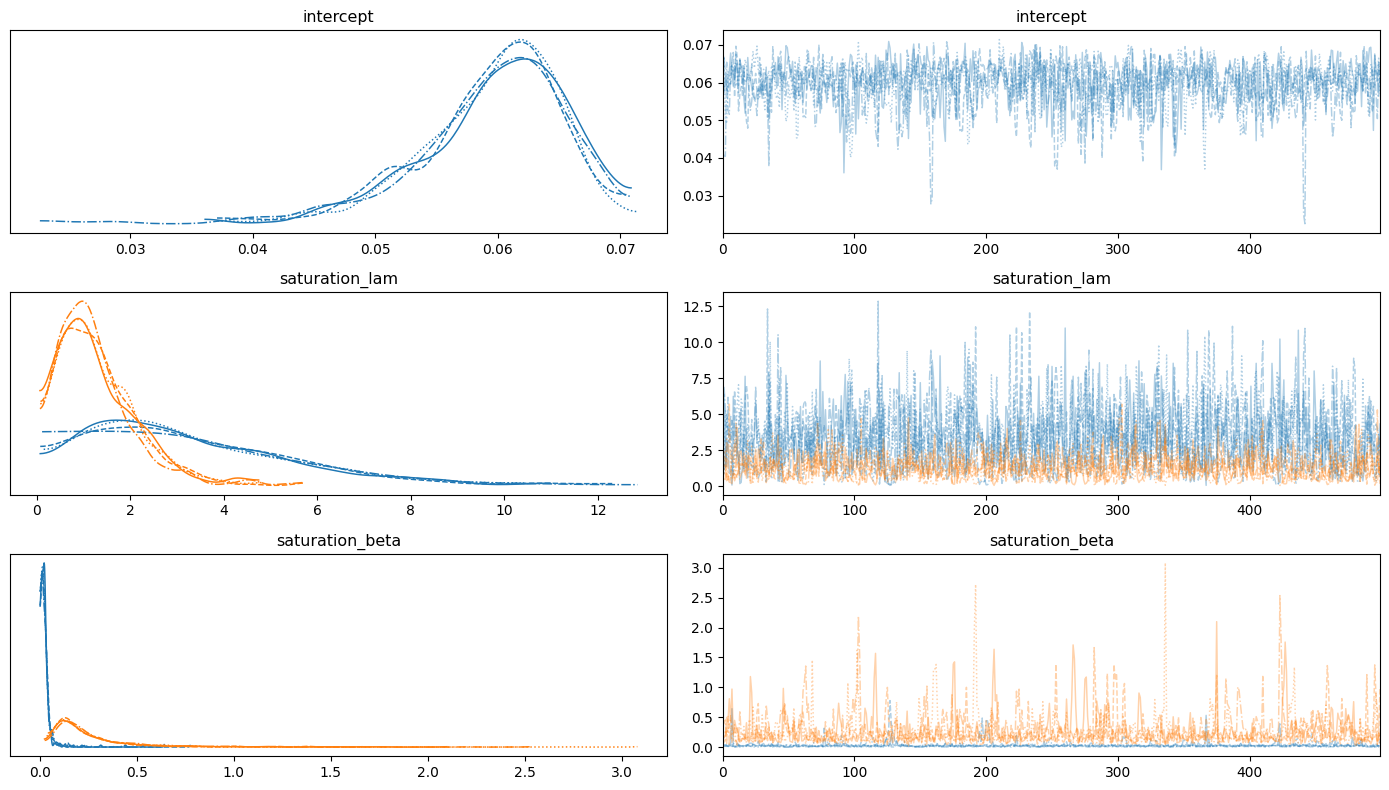

In [25]:
# Trace plots — visualise chain mixing for main parameters
az.plot_trace(
    idata,
    var_names=["intercept", "saturation_lam", "saturation_beta"],
    compact=True,
    figsize=(14, 8),
)
plt.tight_layout()
plt.show()

## Step 5 — Save Posterior Trace

In [26]:
import os, joblib

# ── NetCDF trace (ArviZ / pymc standard format) ───────────────────────────
trace_path = "../data/mmm_trace.nc"
idata.to_netcdf(trace_path)
print(f"Trace saved to  {os.path.abspath(trace_path)}")

# ── Scaler (needed for holdout / production inference) ───────────────────
scaler_path = "../data/mmm_scaler.pkl"
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {os.path.abspath(scaler_path)}")

Trace saved to  c:\Users\Rodrigo Guskuma\Documents\vscode\personal-projects\mmm-analysis\data\mmm_trace.nc
Scaler saved to c:\Users\Rodrigo Guskuma\Documents\vscode\personal-projects\mmm-analysis\data\mmm_scaler.pkl
